<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st 

df_games = pd.read_csv("/datasets/games.csv")

In [2]:
#Paso 1

#Reemplaza los nombres de las columnas (ponlos en minúsculas)
columnas_minus = []
for column in df_games.columns:
    columnas_minus.append(column.lower())
    
df_games.columns = columnas_minus


In [3]:
df_games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
#Paso 2
#Convierte los datos en los tipos necesarios. Arrancamos con "name" y "year_of_release"
 
df_games["name"] = df_games["name"].fillna("Unknown")
df_games["name"].isna().sum()


0

In [5]:

mode_year = df_games["year_of_release"].mode()[0]
df_games["year_of_release"] = df_games["year_of_release"].fillna(mode_year).astype(int)

df_games.info()
#Ahora continuamos con "critic_score" y y "user_score", y convertirlos a int y float, respect


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.4+ MB


In [6]:
mode_critic_score = df_games["critic_score"].mode()[0]
df_games["user_score"] = df_games["user_score"].replace("tbd", np.nan)
mode_user_score = df_games["user_score"].mode()[0] 

df_games["critic_score"] = df_games["critic_score"].fillna(mode_critic_score).astype(int)
df_games["user_score"] = df_games["user_score"].fillna(mode_user_score).astype(float)

df_games.head()

print("La varianza de la crítica de críticos hacia videojuegos en todas las regiones es:", np.var(df_games["critic_score"]))
print("La desviación estándar de la crítica de críticos hacia videojuegos en todas las regiones es:", np.std(df_games["critic_score"]))
print("")
print("La varianza de la crítica de usuarios hacia videojuegos en todas las regiones es:", np.var(df_games["user_score"]))
print("La desviación estándar de la crítica de usuarios hacia videojuegos en todas las regiones es:", np.std(df_games["user_score"]))


La varianza de la crítica de críticos hacia videojuegos en todas las regiones es: 94.82803720839838
La desviación estándar de la crítica de críticos hacia videojuegos en todas las regiones es: 9.73796884408645

La varianza de la crítica de usuarios hacia videojuegos en todas las regiones es: 1.13449099641551
La desviación estándar de la crítica de usuarios hacia videojuegos en todas las regiones es: 1.0651248736253933


In [7]:
#Ahora queda revisar la columna rating
df_games["rating"].unique() # tiene 9 valores distintos
mode_rating = df_games["rating"].mode()[0]

df_games["rating"] = df_games["rating"].fillna(mode_rating)
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.

Respuesta:
Pasé las columnas en minúsculas usando un bucle for para convertirlas.
En la columna year_of_release, calculé la moda, rellené NaN y convertí a int64.
Para las columnas critic_score y user_score, está la gran mejora: reemplacé 'tbd' con np.nan antes de calcular la moda.  Los tipos quedaron int64 y float64 respectivamente.


¿Por qué crees que los valores están ausentes? Brinda explicaciones posibles.

Respuesta:
En la columna year_of_release, no había como tal fecha registrada, entonces tiene sentido que el valor estuviera ausente.
En la columna critic_score y user_score. No todos los juegos reciben reseñas, especialmente los menos populares o los muy antiguos.
En la columna rating, podría ser que algunos juegos muy antiguos fueron lanzados antes de que existiera el sistema ESRB (que comenzó en 1994), así que simplemente no tienen clasificación asignada.

Presta atención a la abreviatura TBD: significa "to be determined" (a determinar). Especifica cómo piensas manejar estos casos.

Respuesta: ya que rating es categórico, entonces la moda es la métrica correcta. Si "E" ya domina el dataset, rellenar NaN con "E" no distorsiona significativamente la distribución. Así pues, se rellenó los valores con fillna()

In [8]:
#Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada
#juego y coloca estos valores en una columna separada.

df_games["total_sales"] = df_games["na_sales"] + df_games["eu_sales"] + df_games["jp_sales"] + df_games["other_sales"]
#Podemos calcular la desviación estándar y varianza para df_games["total_sales"]
print("La varianza de la venta total de videojuegos en todas las regiones es:", np.var(df_games["total_sales"]))
print("La desviación estándar de la venta total de videojuegos en todas las regiones es:", np.std(df_games["total_sales"]))


La varianza de la venta total de videojuegos en todas las regiones es: 2.3969695756565006
La desviación estándar de la venta total de videojuegos en todas las regiones es: 1.5482149642916194


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


In [9]:
#Paso 3

In [10]:
#Mira cuántos juegos fueron lanzados en diferentes años. 

df_games.groupby("year_of_release").count()

,name,platform,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
year_of_release,,,,,,,,,,,
1980,9,9,9,9,9,9,9,9,9,9,9
1981,46,46,46,46,46,46,46,46,46,46,46
1982,36,36,36,36,36,36,36,36,36,36,36
1983,17,17,17,17,17,17,17,17,17,17,17
1984,14,14,14,14,14,14,14,14,14,14,14
1985,14,14,14,14,14,14,14,14,14,14,14
1986,21,21,21,21,21,21,21,21,21,21,21
1987,16,16,16,16,16,16,16,16,16,16,16
1988,15,15,15,15,15,15,15,15,15,15,15


#¿Son significativos los datos de cada período?

Respuesta
En los años 1980-1985 hay alrededor de 100 juegos lanzados, mientras que en los años posteriores, particularmente la década de los 2010 se observa un gran cantidad de juegos lanzados. Se observa el pico en 2008, así pues, se puede concluir que es el año donde se introdujo muchas plataformas o simplemente hubo muchos juegos lanzados por la alta demanda de años anteriores. Podemos considerar que los datos son confiables a partir de 1990 aprox ya que anterior a eso se observan muy pocos juegos registrados y como tal puede que haya más, solo que puede ser posible no se hayan registrado en su año de lanzamiento correctamente

In [11]:
platform_year = df_games.groupby(["platform", "year_of_release"])["total_sales"].sum()
platform_year

platform  year_of_release
2600      1980               11.38
          1981               35.68
          1982               28.88
          1983                5.84
          1984                0.27
                             ...  
XB        2008                6.35
XOne      2013               18.96
          2014               54.07
          2015               60.14
          2016               26.15
Name: total_sales, Length: 246, dtype: float64

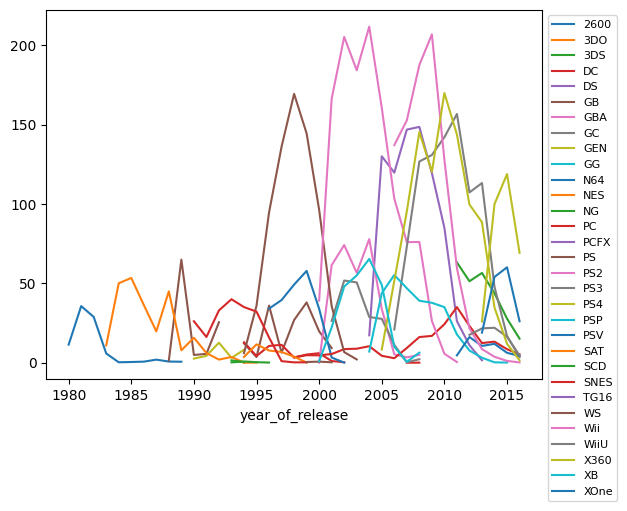

platform             XOne
year_of_release      2016
total_sales        211.81
dtype: object

In [12]:
platform_year = platform_year.reset_index()

platform_year.pivot(columns= "platform", index= "year_of_release", values= "total_sales").plot()
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
plt.show()

platform_year.max()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Buena manera de mostrar los datos, gracias a la gráfica podemos observar el ciclo de vida de cada una de las plataformas
</div>


Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

Respuesta
Las plataformas con las mayores ventas totales  son DS, Wii, GB, XOne y PS2. Curiosamente estas son plataformas que antes tenían ventas y ahora ya no, esto se debe a que se descontinuó la plataforma. DC es otra que tuvo un auge, pero ya no más. Incluso podemos incluir N64, 3DO y GEN. El periodo que tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer es de 10 años.

Para tomar datos que nos permitirtan construir un modelo para 2017, podemos empezar desde el 2007 ya que encontramos que son aprox 10 años del ciclo de vida de cada plataforma. Nos daría una buena estimación a que nos podríamos esperar. Así, si el ciclo de vida de una plataforma es de ~10 años, y queremos predecir 2017, tiene mucho sentido tomar datos desde 2007 en adelante, ya que esas plataformas serían las que aún estarían activas o en su etapa relevante. 

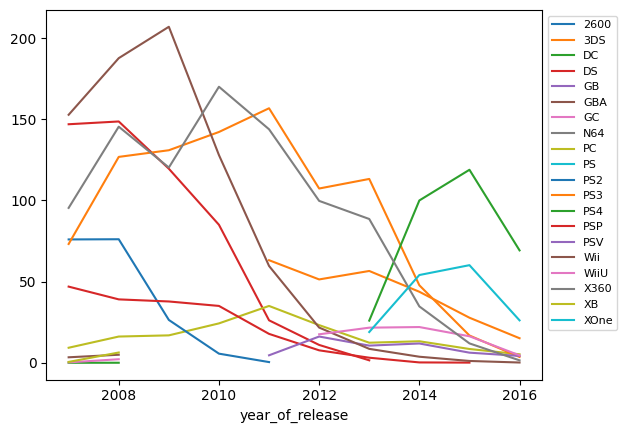

In [13]:
platform_2006 = platform_year[platform_year["year_of_release"] > 2006]
platform_2006 = platform_2006.reset_index()
platform_2006

platform_2006.pivot(columns= "platform", index= "year_of_release", values= "total_sales").plot()
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
plt.show()


¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables

Respuesta
En nuestros datos para platform_2006 encontramos que las plataformas líderes en ventas son GBA, GB, DS y PS3 pero en el año 2009, principalmente. En realidad, se ve una reducción en el año 2016, es decir, para el 2017 habrá ventas más bajas.

Pueede ser que GBA y GB son dos plataformas irrelevantes para predecir 2017 ya que se encuentran un poco lejos de las predicciones y ya no existen (descontinuadas) como tal para decidir algo a futuro.

Puede ser también porque los valored de 2016 están incompletos y por eso no tenemos tantos datos sobre este año para observar bien sus ventas.


<Figure size 2000x600 with 0 Axes>

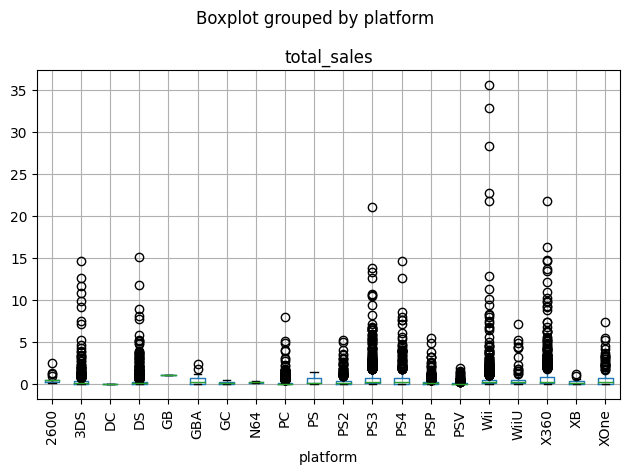

In [14]:
#Creando un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma.

platform_2006_box = df_games[df_games["year_of_release"] > 2006]

plt.figure(figsize=(20, 6))
platform_2006_box.boxplot(by="platform", column="total_sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los valores atipicos impiden que podamos apreciar las cajas correctamente. Recomiendo utilizar el parametro `showfliers = False` el cual nos ayuda a remover estos valores atipicos. Te dejo un ejemplo en la celda de abajo
</div>


<Figure size 2000x600 with 0 Axes>

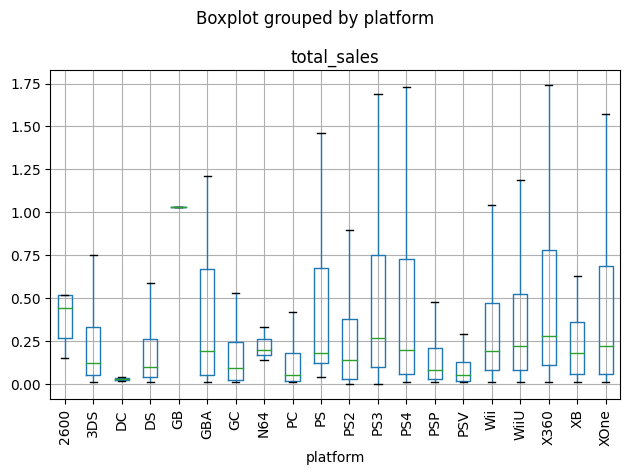

In [15]:
plt.figure(figsize=(20, 6))
platform_2006_box.boxplot(by="platform", column="total_sales", showfliers = False) # <- Nuevo parametro aquí
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

Respuesta: Las ventas cambian bastante entre plataformas ya que la mediana para GB, GBA, PS y X360 son las más significativas. Las ventas en varias plataformas tienen valores muy cercanos en los cuartiles Q1 a Q3. Encontramos valores muy extremos en ciertos juegos para varias plataformas como el Wii que tiene juegos que superaron 30 millones de dolares en venta, sin embargo, son insuficientes para aumentar tanto su venta promedio como los tantos exitosos que tuvo GB.



In [16]:
#Creando un gráfico de dispersión y calculando la correlación entre las reseñas y las 
#ventas, y viendo como las reseñas de usuarios y profesionales afectan las ventas de 
#una plataforma popular

wii_platform = df_games[df_games["platform"] == "Wii"][["critic_score","user_score", "total_sales"]] #Eligiendo la plataforma wii
wii_corr = wii_platform.corr()
wii_corr

,critic_score,user_score,total_sales
critic_score,1.000000,0.484480,0.115085
user_score,0.484480,1.000000,0.033155
total_sales,0.115085,0.033155,1.000000


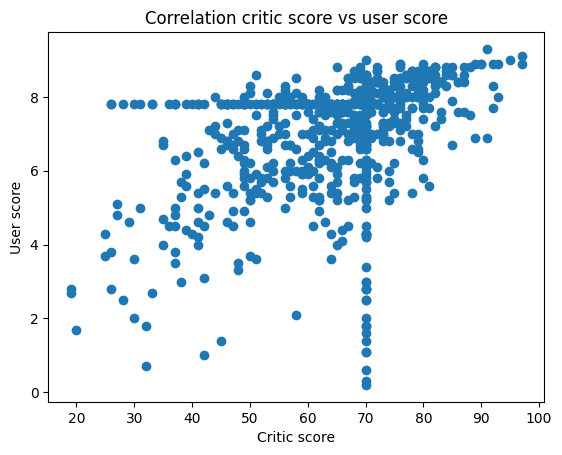

In [17]:
plt.scatter(x = wii_platform["critic_score"], y = wii_platform["user_score"])
plt.title("Correlation critic score vs user score")  
plt.xlabel("Critic score")  
plt.ylabel("User score")  
plt.show()


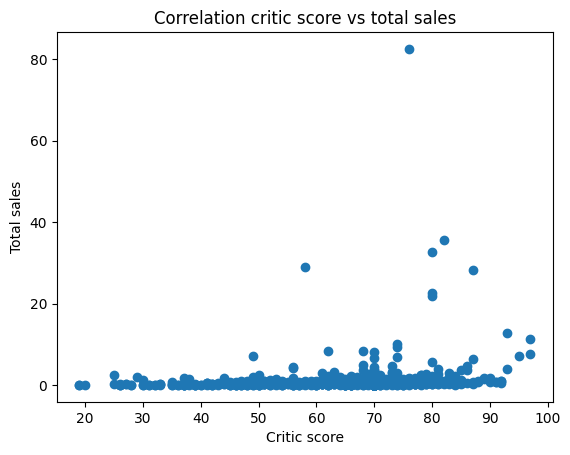

In [18]:
plt.scatter(x = wii_platform["critic_score"], y = wii_platform["total_sales"])
plt.title("Correlation critic score vs total sales")  
plt.xlabel("Critic score")  
plt.ylabel("Total sales") 
plt.show()

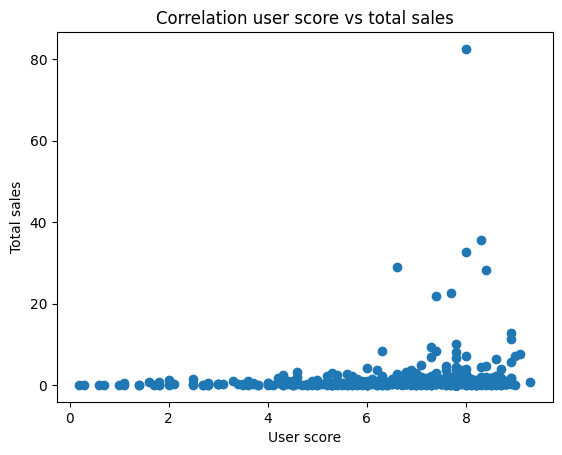

In [19]:
plt.scatter(x = wii_platform["user_score"], y = wii_platform["total_sales"])
plt.title("Correlation user score vs total sales")  
plt.xlabel("User score")  
plt.ylabel("Total sales") 
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar la correlación entre las ventas y las reseñas, como bien mencionas la correlación es debil-moderada por lo que no siempre las buenas reseñas van a implicar un gran numero de ventas
</div>


Notamos que las correlaciones son de

critic_score vs total_sales: 0.115 → correlación positiva muy débil
user_score vs total_sales: 0.033 → correlación casi inexistente
critic_score vs user_score: 0.484 → correlación moderada

Esto nos indica que los gustos o predicciones de los críticos no suelen tener mucha confianza para las ventas del producto de la plataforma Wii, es decir, puede que lo hayan evaluado muy alto o muy bajo, mientras que las ventas del juego pudieron ser muy bajos o muy alto, respectivamente.

Sucede distinto con la evaluación del usuario. Su eficiencia de evaluación de un juego según sus ventas al parecer es un poco más bajo que critic_score vs total_sales.

Finalmente notamos que los críticos y los usuarios suelen tener evaluaciones muy cercanas con una correlación moderada de 0.484, es decir, si uno evaluaba un juego en 8.0, puede que el otro lo haya evaluado en 81, por ejemplo.

<Figure size 2000x600 with 0 Axes>

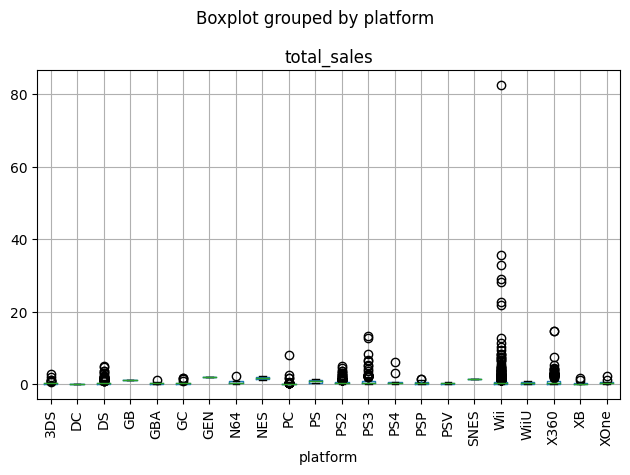

In [20]:
#Comparando las ventas de los mismos juegos en otras plataformas

name_platform = df_games.groupby(["name", "platform"])["total_sales"].sum().reset_index()
wii_games = name_platform[name_platform["platform"] == "Wii"]
all_platform = name_platform["name"].isin(wii_games["name"])   
platform_games = name_platform[all_platform]

plt.figure(figsize=(20, 6))
platform_games.boxplot(by="platform", column="total_sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



Podemos ver que en las plataformas PS3, X360, PC y DS se tienen buenas ventas los juegos que también están en Wii. Sin embargo, la plataforma Wii tiene ventas más altas comparada con las otras, y por bastante. La plataforma con valores atípicos (outliers) muy llamativos podría ser en este caso Wii, PS3 y X360.



<Figure size 2000x600 with 0 Axes>

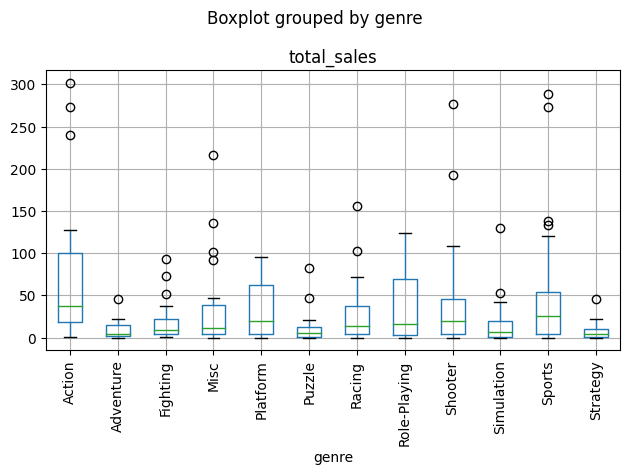

In [21]:
#Echando un vistazo a la distribución general de los juegos por género
genre_platform = df_games.groupby(["genre", "platform"])["total_sales"].sum().reset_index()

plt.figure(figsize=(20, 6))
genre_platform.boxplot(by = "genre", column = "total_sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

Respuesta: Los géneros que tienen las medianas más altas son Action, Platform, Sports, Shooter y Role-Playing, estos son consistentemente más rentables.
Los géneros que tienen los outliers más extremos podría indicar que hay algunos juegos "blockbuster" que jalan las ventas hacia arriba, pero que no son la norma.
Los géneros con cajas (IQR) muy amplias, significaría que las ventas son muy variables dentro de ese género.

In [22]:
#Paso 4

In [23]:
best_na_platform = df_games.groupby(["platform"])["na_sales"].sum().reset_index().sort_values(by = "na_sales", ascending = False).reset_index()
best_eu_platform = df_games.groupby(["platform"])["eu_sales"].sum().reset_index().sort_values(by = "eu_sales", ascending = False).reset_index()
best_jp_platform = df_games.groupby(["platform"])["jp_sales"].sum().reset_index().sort_values(by = "jp_sales", ascending = False).reset_index()


In [24]:
best_na_platform.drop("index", axis = 1).head()

,platform,na_sales
0,X360,602.47
1,PS2,583.84
2,Wii,496.90
3,PS3,393.49
4,DS,382.40


In [25]:
best_eu_platform.drop("index", axis = 1).head()

,platform,eu_sales
0,PS2,339.29
1,PS3,330.29
2,X360,270.76
3,Wii,262.21
4,PS,213.61


In [26]:
best_jp_platform.drop("index", axis = 1).head()

,platform,jp_sales
0,DS,175.57
1,PS,139.82
2,PS2,139.20
3,SNES,116.55
4,3DS,100.67


Encontramos que las cinco plataformas principales son un poco distintas para cada región.
Para Norteamérica encontramos los valores máximos de ventas para las plataformas X360, PS2, Wii, PS3 y DS.
Para la Unión europea vemos las principales: PS2, PS3, x360, Wii y PS.
Para Japón encontramos DS, PS, PS2, SNES, 3DS.

Es evidente que las plataformas principales de cada país son de las empresas dominantes de su mercado local, es decir, para Norteamérica son Microsoft y Sony con X360 y PS2, respectivamente. Para Europa encontramos en su mayoría Play Station, mientras que para Japón, varios derivados de Nintendo como el DS, SNES y 3DS.



In [27]:
#Los cinco géneros principales
best_na_genre = df_games.groupby(["genre"])["na_sales"].sum().reset_index().sort_values(by = "na_sales", ascending = False).reset_index()
best_eu_genre = df_games.groupby(["genre"])["eu_sales"].sum().reset_index().sort_values(by = "eu_sales", ascending = False).reset_index()
best_jp_genre = df_games.groupby(["genre"])["jp_sales"].sum().reset_index().sort_values(by = "jp_sales", ascending = False).reset_index()


In [28]:
best_na_genre.drop("index", axis = 1).head()

,genre,na_sales
0,Action,879.01
1,Sports,684.43
2,Shooter,592.24
3,Platform,445.50
4,Misc,407.27


In [29]:
best_eu_genre.drop("index", axis = 1).head()

,genre,eu_sales
0,Action,519.13
1,Sports,376.79
2,Shooter,317.34
3,Racing,236.51
4,Misc,212.74


In [30]:
best_jp_genre.drop("index", axis = 1).head()

,genre,jp_sales
0,Role-Playing,355.41
1,Action,161.43
2,Sports,135.54
3,Platform,130.83
4,Misc,108.11


Ahora para los géneros, las ventas principalmente se concentran en "Action", independientemente de la región. Notamos también que es mucha la diferencia de las ventas que hace "Action" en Norteamérica, en contraste con la suma de los cinco primeros géneros de Japón que muestra en total 891.32 millones, mientras que "Action" por si solo en Norteamérica suma 879.01 millones, esto puede ser bien por la inmensa diferencia poblacional.

También notamos que los tres primeros géneros de Norteamérica y Europa coinciden, sin embargo, en Japón domina el género Role-Playing y no consideran comprar mucho juegos "Shooting" como en América y Europa.

In [31]:
#Las clasificaciones de ESRB afectan a las ventas en regiones individuales
best_na_rating = df_games.groupby(["rating"])["na_sales"].sum().reset_index().sort_values(by = "na_sales", ascending = False).reset_index()
best_eu_rating = df_games.groupby(["rating"])["eu_sales"].sum().reset_index().sort_values(by = "eu_sales", ascending = False).reset_index()
best_jp_rating = df_games.groupby(["rating"])["jp_sales"].sum().reset_index().sort_values(by = "jp_sales", ascending = False).reset_index()



In [32]:
best_na_rating.drop("index", axis = 1).head()

,rating,na_sales
0,E,2535.45
1,T,759.75
2,M,748.48
3,E10+,353.32
4,K-A,2.56


In [33]:
best_eu_rating.drop("index", axis = 1).head()

,rating,eu_sales
0,E,1324.08
1,M,483.97
2,T,427.03
3,E10+,188.52
4,AO,0.61


In [34]:
best_jp_rating.drop("index", axis = 1).head()

,rating,jp_sales
0,E,1040.07
1,T,151.40
2,M,64.24
3,E10+,40.20
4,K-A,1.46


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los resultados de los últimos ejercicios son correctos, sin embargo recomiendo resaltar los resultados con gráficas que muestren las diferencias/similitudes entre las regiones
</div>


Notamos que las clasificaciones ESRB son demasiado similares de todas las regiones, particularmente las primeras 4 en todas las regiones son exactamente las mismas con la única diferencia que en "eu" se tiene "T" en segundo lugar de ventas y "M" en tercer lugar, mientras que en "na" y "jp" se tiene "T" en tercer lugar de ventas y "M" en segundo lugar, esto puede estar relacionado con las preferencias culturales que ya identificadas anteriormente ya que habíamos visto que EU prefiere menos los juegos de tipo Shooter, que suelen tener clasificación "M". Hay una diferencia muy significativa en ventas entre el 4to lugar y el 5to en cualquier región, es decir, las primeras cuatro clasificaciones dominan el mercado de ventas de cualquier región.

Así pues, la clasificación ESRB sí afecta las ventas ya que la clasificación "E" se puede adquirir por cualquier comprador sin importar la edad. Mientras que vas aplicando más filtros para comprar un juego, las ventas se ven afectadas.

Para maximizar ventas globales, podemos orientarnos mucho a las ventas de clasificación "E", principalmente.

In [35]:
#Paso 5

In [36]:
#Hipótesis nula: Las calificaciones promedio de los usuarios para las plataformas 
#Xbox One y PC son las mismas
#Hipótesis alternativa: Las calificaciones promedio de los usuarios para las plataformas 
#Xbox One y PC son diferentes
df_xone = df_games[df_games["platform"] == "XOne"]["user_score"]
df_pc = df_games[df_games["platform"] == "PC"]["user_score"]

In [37]:

p_value = st.ttest_ind(df_xone, df_pc)
p_value.pvalue
alpha = 0.05

if (p_value.pvalue > alpha):
    print("No podemos rechazar la hipótesis nula")
else:
    print("Rechazamos la hipótesis nula")

Rechazamos la hipótesis nula


Se rechazó la hipótesis nula, así que los promedios para ambas calificaciones es distinta. Con el p-value de 0.000263 < 0.05, se tiene un margen bastante alto para rechazar la hipótesis. Entonces podemos decir que los usuarios suelen calificar de distintas maneras cada plataforma, indicando más gusto por una que por otra, como un tipo favoritismo.

In [38]:
print("Media XOne:", df_xone.mean())
print("Media PC:", df_pc.mean())

Media XOne: 6.857894736842105
Media PC: 7.216940451745379


In [39]:
#Hipótesis nula: Las calificaciones promedio de los usuarios para los géneros para 
#Action vs Sports son las mismas
#Hipótesis alternativa: Las calificaciones promedio de los usuarios para los géneros para 
#Action vs Sports son diferentes.
df_action = df_games[df_games["genre"] == "Action"]["user_score"]
df_sports = df_games[df_games["genre"] == "Sports"]["user_score"]

In [40]:
p_value = st.ttest_ind(df_action, df_sports)
p_value.pvalue
alpha = 0.05

if (p_value.pvalue > alpha):
    print("No podemos rechazar la hipótesis nula")
else:
    print("Rechazamos la hipótesis nula")


No podemos rechazar la hipótesis nula


Entonces encontramos que la hipótesis nula no fue rechazada, es decir, que los promedios calificaciones de usuarios para los géneros de Acción y Deportes son muy similares. Así pues

In [41]:
print("Media Acción:", df_action.mean())
print("Media Deportes:", df_sports.mean())

Media Acción: 7.394805580290887
Media Deportes: 7.405962521294717


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


In [42]:
#Paso 6

Para la preparación de datos hubo que recordar cómo en el sprint 1 se iba limpiando y mejorando los str de nombre de columnas y trabajar con ellas. Quizá esto se hace porque será algo muy común trabajar con ello como científico de datos. 

Además, hubo varios momentos donde se iba agrupando datos en su forma más básica como por plataforma, por género y por calificaciones. Todo esto remontó al sprint 4 y 5 donde se trabajó también con como mostrar las correlaciones entre las columnas y si era factible decidir si una u otra "dependía" o mostraba comportamientos similares. 

Cuando estaba trabajando exclusivamente con las regiones y sus ventas según las agrupaciones por plataforma, género y clasificación encontramos que muchas veces estos afectan siginificativamente sus ventas, especialmente la clasificación de los videojuegos y volverlos fácilmente adquiribles, tal como la clasificación "E". 

Las comprobaciones de hipótesis son la forma correcta de verificar si podemos decidir algo sobre el futuro para nuestro trabajo, es decir, podríamos predecir futuros comportamientos. Así, si tuviera que recomendar una estrategia para maximizar ventas de videojuegos en 2017 podría ser que se enfoquen en las plataformas, clasificaciones, géneros para cada región particular. Podemos explotar esos hallazgos, ya que puede ser altamente probablemente que estos resultados está correlacionado con la cultura de dichas zonas geográficas

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- El proyecto esta ordenado y limpio
    
</div>
